# Source Detection Module — Standalone Validation

This notebook runs the standalone `source_detection` module,
compares with original pipeline results, and visualizes detected neurons.

**Pipeline stage:** corrected video → detect seeds → build ROI footprints → extract traces

## 1. Setup & Imports

In [1]:

import sys, pickle
from pathlib import Path

SEP_DIR = Path(".").resolve()
# walk up until we find the separation folder
while SEP_DIR.name != "separation" and SEP_DIR != SEP_DIR.parent:
    SEP_DIR = SEP_DIR.parent
if SEP_DIR.name != "separation":
    SEP_DIR = Path(".").resolve()

sys.path.insert(0, str(SEP_DIR))
REPO_ROOT = SEP_DIR.parent
TEST_DATA = SEP_DIR / "_test_data"
print(f"Separation dir: {SEP_DIR}")
print(f"Repo root: {REPO_ROOT}")


Separation dir: /home/yz/MIN1PIPE/separation
Repo root: /home/yz/MIN1PIPE


In [2]:

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.ndimage import gaussian_filter

# ── Inline visualization helpers (from MIN1PIPE repo) ──

def normalize_vis(frame_in, dim=None):
    """Normalize intensity to [0, 1]. (from utilities/elements/normalize.m)"""
    arr = np.asarray(frame_in, dtype=np.float64)
    if arr.size == 0:
        return arr
    if dim is None or int(dim) == 4:
        mn = np.nanmin(arr)
        out = arr - mn
        mx = np.nanmax(out)
        if mx == 0 or np.isnan(mx):
            return np.zeros_like(out)
        return out / mx
    axis = int(dim) - 1 if int(dim) > 0 else int(dim)
    mn = np.nanmin(arr, axis=axis, keepdims=True)
    out = arr - mn
    mx = np.nanmax(out, axis=axis, keepdims=True)
    safe = np.where(mx == 0, 1.0, mx)
    out = out / safe
    return np.where(mx == 0, 0.0, out)


def plot_contour_standalone(roifn, sigfn, seedsfn, imax, pixh, pixw, ax=None):
    """Plot ROI contours on max-projection. (from postprocess/plot_contour.m)"""
    roi = np.asarray(roifn, dtype=np.float64)
    sig = np.asarray(sigfn, dtype=np.float64)
    seeds = np.asarray(seedsfn).reshape(-1)
    imax_arr = np.asarray(imax, dtype=np.float64)
    pixh_i, pixw_i = int(pixh), int(pixw)
    n_pixels = pixh_i * pixw_i

    if roi.shape[0] != n_pixels and roi.shape[1] == n_pixels:
        roi = roi.T

    if ax is None:
        ax = plt.gca()
    ax.imshow(imax_arr, vmin=0.0, vmax=0.8, cmap="viridis", origin="upper",
              interpolation="nearest")

    n_ids = min(roi.shape[1], sig.shape[0], seeds.shape[0])
    for idx in range(n_ids):
        tmp = roi[:, idx].reshape((pixh_i, pixw_i)) * float(np.max(sig[idx, :]))
        tmp = gaussian_filter(tmp, sigma=3.0)
        level = float(np.max(tmp) * 0.8)
        if not np.isfinite(level) or level <= 0:
            continue
        cs = ax.contour(np.flipud(tmp), levels=[level], colors="none")
        for seg in cs.allsegs[0]:
            if seg.shape[0] < 2:
                continue
            ax.plot(seg[:, 0], pixh_i - seg[:, 1], "r", linewidth=1.0)
        if hasattr(cs, "remove"):
            cs.remove()
        y, x = np.unravel_index(int(seeds[idx]), (pixh_i, pixw_i))
        ax.text(x + 1, y + 1, str(idx + 1), fontsize=9, color="white")

    ax.set_title("Neural Contours")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(0, pixw_i - 1)
    ax.set_ylim(pixh_i - 1, 0)


def plot_traces(sigfn, ax=None, title="Traces"):
    """Plot stacked normalized traces. (from demo_min1pipe.m)"""
    if ax is None:
        ax = plt.gca()
    sigt = np.asarray(sigfn, dtype=np.float64).copy()
    for i in range(sigt.shape[0]):
        sigt[i, :] = normalize_vis(sigt[i, :])
    ax.plot((sigt + np.arange(1, sigt.shape[0] + 1)[:, None]).T)
    ax.axis("tight")
    ax.set_title(title)
    ax.set_xlabel("Frame")
    ax.set_ylabel("Component")


def plot_mc_scores(raw_score, corr_score, ax=None, title="MC Scores"):
    """Plot motion correction quality scores."""
    if ax is None:
        ax = plt.gca()
    ax.plot(raw_score, label="raw_score", alpha=0.8)
    ax.plot(corr_score, label="corr_score", alpha=0.8)
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("Frame")
    ax.set_ylabel("Displacement (px)")


def similarity_report(name, actual, expected, rtol=1e-5, atol=1e-7):
    """Compute and print similarity metrics between two arrays."""
    actual = np.asarray(actual, dtype=np.float64)
    expected = np.asarray(expected, dtype=np.float64)
    if actual.shape != expected.shape:
        print(f"  {name}: SHAPE MISMATCH actual={actual.shape} expected={expected.shape}")
        return False
    abs_diff = np.abs(actual - expected)
    max_abs = float(np.max(abs_diff))
    mean_abs = float(np.mean(abs_diff))
    exp_max = float(np.max(np.abs(expected)))
    rel_err = max_abs / max(exp_max, 1e-10)
    corr = float(np.corrcoef(actual.ravel(), expected.ravel())[0, 1]) if actual.size > 1 else 1.0
    match = np.allclose(actual, expected, rtol=rtol, atol=atol)
    status = "PASS" if match else "FAIL"
    print(f"  [{status}] {name}:")
    print(f"       shape={actual.shape}  max_abs_diff={max_abs:.2e}  "
          f"mean_abs_diff={mean_abs:.2e}  rel_err={rel_err:.2e}  corr={corr:.6f}")
    return match


def plot_comparison_images(img1, img2, title1, title2, suptitle=""):
    """Side-by-side image comparison with difference map."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    axes[0].imshow(img1, cmap="viridis", origin="upper", interpolation="nearest")
    axes[0].set_title(title1)
    axes[1].imshow(img2, cmap="viridis", origin="upper", interpolation="nearest")
    axes[1].set_title(title2)
    diff = np.abs(np.asarray(img1, dtype=np.float64) - np.asarray(img2, dtype=np.float64))
    im = axes[2].imshow(diff, cmap="hot", origin="upper", interpolation="nearest")
    axes[2].set_title(f"Abs Difference (max={float(np.max(diff)):.2e})")
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    plt.tight_layout()
    plt.show()


## 2. Load Reference Data

In [3]:
with open(TEST_DATA / "source_detection" / "test_input.pkl", "rb") as f:
    ref_input = pickle.load(f)
with open(TEST_DATA / "source_detection" / "test_output.pkl", "rb") as f:
    ref_output = pickle.load(f)

print("Parameters:", ref_input["params"])
print(f"Input corrected_video: {ref_input['corrected_video'].shape}")
print(f"Input imax: {ref_input['imax'].shape}")
print(f"Reference components: {ref_output['n_components']}")
print(f"Reference roifn: {ref_output['roifn'].shape}")
print(f"Reference sigfn: {ref_output['sigfn'].shape}")

Parameters: {'neuron_size': 5.0, 'max_seeds': 80}
Input corrected_video: (500, 75, 75)
Input imax: (75, 75)
Reference components: 9
Reference roifn: (5625, 9)
Reference sigfn: (9, 500)


## 3. Run Standalone Module

In [4]:
from source_detection import run_source_detection

result = run_source_detection(
    corrected_video=ref_input["corrected_video"],
    imax=ref_input["imax"],
    params=ref_input["params"],
)

print(f"Detected components: {result.n_components}")
print(f"ROI shape: {result.roifn.shape}")
print(f"Signal shape: {result.sigfn.shape}")
print(f"Seeds: {result.seedsfn}")

Detected components: 9
ROI shape: (5625, 9)
Signal shape: (9, 500)
Seeds: [1902 3396 4995 3914 4311 4142 3849 4304 2070]


## 4. Numerical Comparison

In [5]:
print("=" * 70)
print("NUMERICAL COMPARISON: Standalone vs Original Pipeline")
print("=" * 70)

all_pass = True
all_pass &= similarity_report("roifn", result.roifn, ref_output["roifn"])
all_pass &= similarity_report("sigfn", result.sigfn, ref_output["sigfn"])
all_pass &= similarity_report("seedsfn", result.seedsfn, ref_output["seedsfn"])
n_match = result.n_components == ref_output["n_components"]
_nm_status = "PASS" if n_match else "FAIL"
print(f"  [{_nm_status}] n_components: "
      f"{result.n_components} vs {ref_output['n_components']}")
all_pass &= n_match

_status = "SUCCESS" if all_pass else "FAILURE"
print(f"\nOVERALL: {_status}")

NUMERICAL COMPARISON: Standalone vs Original Pipeline
  [PASS] roifn:
       shape=(5625, 9)  max_abs_diff=0.00e+00  mean_abs_diff=0.00e+00  rel_err=0.00e+00  corr=1.000000
  [PASS] sigfn:
       shape=(9, 500)  max_abs_diff=0.00e+00  mean_abs_diff=0.00e+00  rel_err=0.00e+00  corr=1.000000
  [PASS] seedsfn:
       shape=(9,)  max_abs_diff=0.00e+00  mean_abs_diff=0.00e+00  rel_err=0.00e+00  corr=1.000000
  [PASS] n_components: 9 vs 9

OVERALL: SUCCESS


## 5. Visualization: Detected Seeds on Max Projection

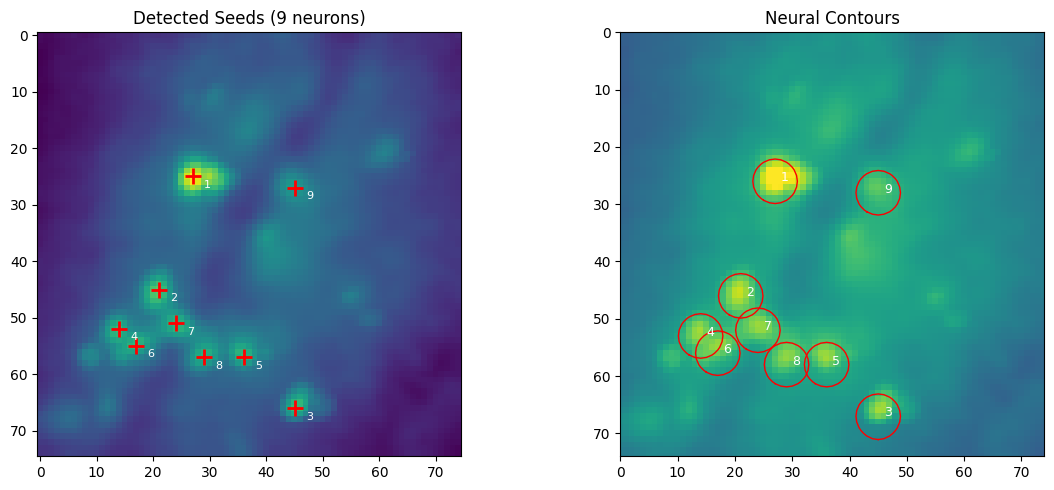

In [6]:
imax = ref_input["imax"]
pixh, pixw = imax.shape

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Seeds as scatter
axes[0].imshow(imax, cmap="viridis", origin="upper", interpolation="nearest")
for i, s in enumerate(result.seedsfn):
    y, x = np.unravel_index(int(s), (pixh, pixw))
    axes[0].plot(x, y, "r+", markersize=12, markeredgewidth=2)
    axes[0].text(x+2, y+2, str(i+1), fontsize=8, color="white")
axes[0].set_title(f"Detected Seeds ({result.n_components} neurons)")
axes[0].set_aspect("equal")

# ROI contours
plot_contour_standalone(result.roifn, result.sigfn, result.seedsfn,
                       imax, pixh, pixw, ax=axes[1])
plt.tight_layout()
plt.show()

## 6. Visualization: Calcium Traces

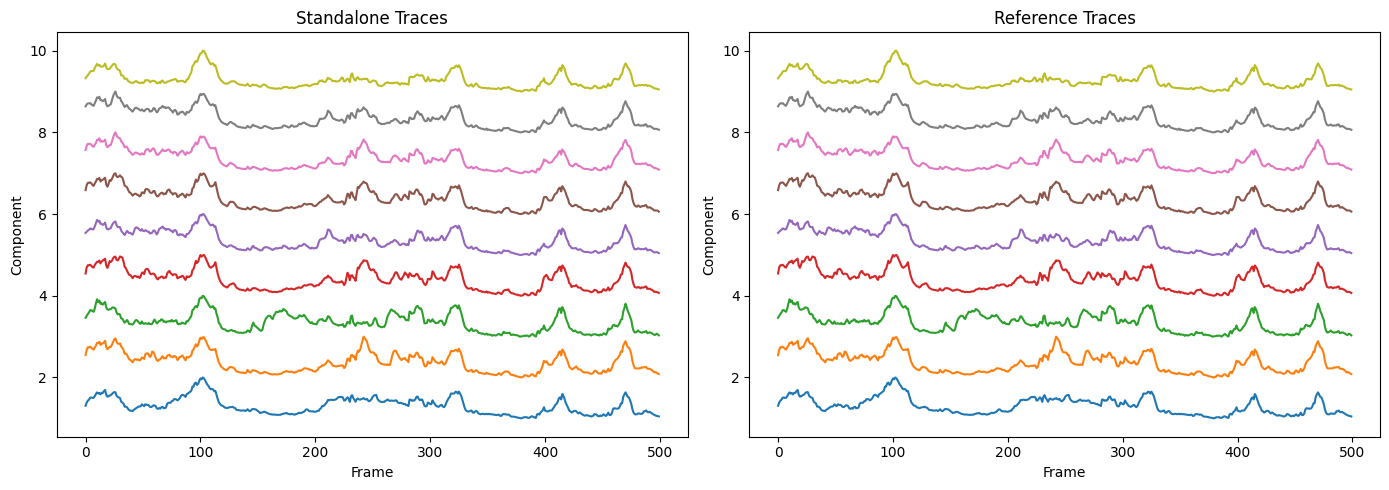

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_traces(result.sigfn, ax=axes[0], title="Standalone Traces")
plot_traces(ref_output["sigfn"], ax=axes[1], title="Reference Traces")
plt.tight_layout()
plt.show()

## 7. Visualization: ROI Spatial Footprints

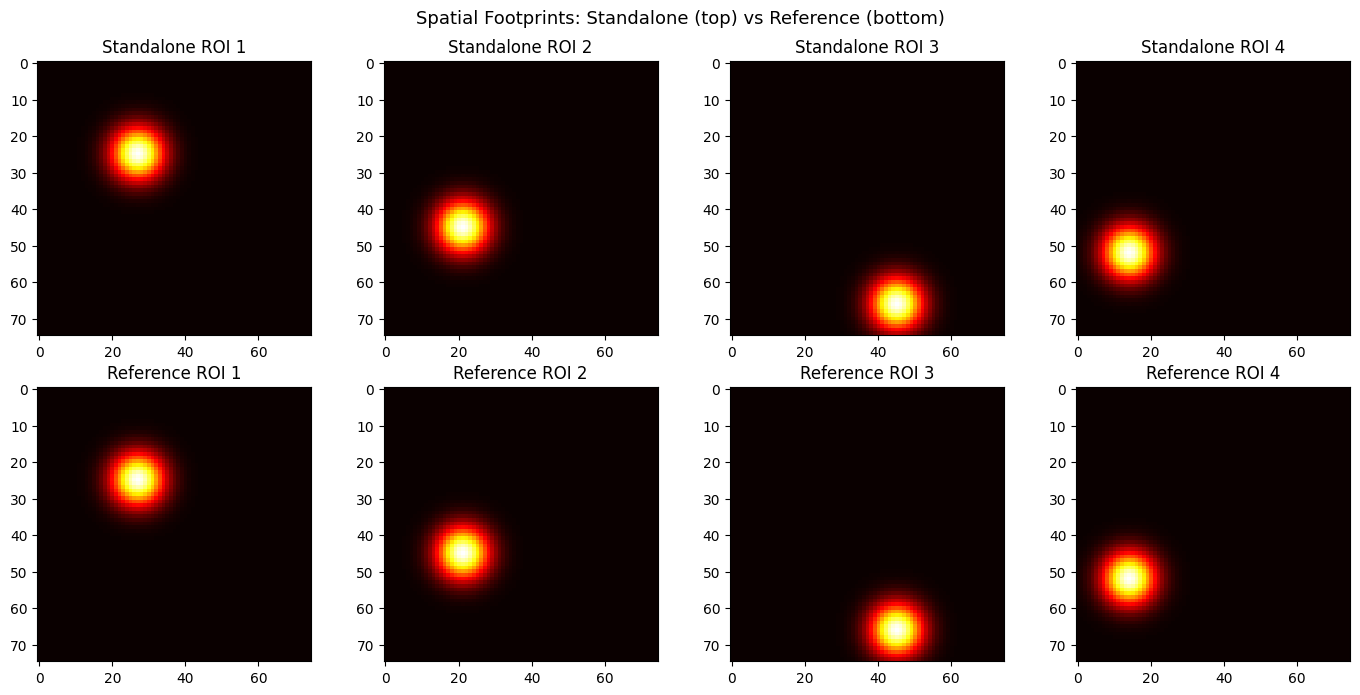

In [8]:
# Show first 4 ROIs side by side
n_show = min(4, result.n_components)
fig, axes = plt.subplots(2, n_show, figsize=(3.5*n_show, 7))
for i in range(n_show):
    roi_img = result.roifn[:, i].reshape(pixh, pixw)
    ref_roi_img = ref_output["roifn"][:, i].reshape(pixh, pixw)
    axes[0, i].imshow(roi_img, cmap="hot", origin="upper", interpolation="nearest")
    axes[0, i].set_title(f"Standalone ROI {i+1}")
    axes[1, i].imshow(ref_roi_img, cmap="hot", origin="upper", interpolation="nearest")
    axes[1, i].set_title(f"Reference ROI {i+1}")
plt.suptitle("Spatial Footprints: Standalone (top) vs Reference (bottom)", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Summary

In [9]:
print("=" * 70)
print("SOURCE DETECTION MODULE — VALIDATION SUMMARY")
print("=" * 70)
print(f"  Components detected: {result.n_components}")
print(f"  ROI shape: {result.roifn.shape}")
print(f"  Signal shape: {result.sigfn.shape}")
_match = "YES" if all_pass else "NO"
_stat = "PASS" if all_pass else "FAIL"
print(f"  All fields match: {_match}")
print(f"  Status: {_stat}")
print("=" * 70)

SOURCE DETECTION MODULE — VALIDATION SUMMARY
  Components detected: 9
  ROI shape: (5625, 9)
  Signal shape: (9, 500)
  All fields match: YES
  Status: PASS
